## Chronic Kidney Disease

The main objective of this project is to develop a robust and accurate predective model for use in diagnosis based on specific markers or features.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

## Member 1 (Celica) - Data Cleaning

In [3]:
# first let's import the dataset and explore it

df = pd.read_csv('chronic_kindey_disease.csv', na_values='?') # missing values are denoted by ? - let's replace them with pandas NaN values
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,status
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [4]:
# to understand better the columns, let's look at the info file of the dataset

with open("chronic_kidney_disease_info.txt", "r") as f:
    content = f.read()

print(content)

% 1. Title: Early stage of Indians Chronic Kidney Disease(CKD)
%
% 2. Source Information:
%   (a) Source: 
			Dr.P.Soundarapandian.M.D.,D.M
			(Senior Consultant Nephrologist), 
			Apollo  Hospitals, 
			Managiri,
			Madurai Main Road, 
			Karaikudi,
			Tamilnadu,
			India.

%   (b) Creator: 
			L.Jerlin Rubini(Research Scholar)
			Alagappa University,
			EmailId   :jel.jerlin@gmail.com
			ContactNo :+91-9597231281

%   (c) Guided by: 
			Dr.P.Eswaran Assistant Professor,
			Department of Computer Science and Engineering,
			Alagappa University,
			Karaikudi,
			Tamilnadu,
			India.
			Emailid:eswaranperumal@gmail.com

%   (d) Date     : July 2015
%
% 3.Relevant Information:
			age		-	age	
			bp		-	blood pressure
			sg		-	specific gravity
			al		-   	albumin
			su		-	sugar
			rbc		-	red blood cells
			pc		-	pus cell
			pcc		-	pus cell clumps
			ba		-	bacteria
			bgr		-	blood glucose random
			bu		-	blood urea
			sc		-	serum creatinine
			sod		-	sodium
			pot		-	potassium
			hemo		-	hem

We see there are 25 columns and 400 rows. Out of the 25 columns, 11 are numeric and 14 are nominal. Out of the 400 rows, there are 250 cases of chronic kindey disease and 150 cases of not CKD. The "patient identifier" is their age (even though this is not a unique value), and then we have the results of several lab tests of this patient, and then in the 'status' column whether the patient has CKD or not.

In [5]:
# check if there are any duplicates

df.duplicated().sum()

# no duplicates, so no need to drop anything

np.int64(0)

In [6]:
# we will also replace yes by 1 and no by 0, and present by 1 and notpresent by 0, etc.

df['rbc'] = df['rbc'].replace({'normal':1, 'abnormal':0})
df['pc'] = df['pc'].replace({'normal':1, 'abnormal':0})
df['pcc'] = df['pcc'].replace({'notpresent':0, 'present':1})
df['ba'] = df['ba'].replace({'notpresent':0, 'present':1})

df['htn'] = df['htn'].replace({'no':0, 'yes':1})
df['dm'] = df['dm'].replace({'\tno':'no'})
df['dm'] = df['dm'].replace({'no':0, 'yes':1})
df['cad'] = df['cad'].replace({'no':0, 'yes':1})
df['appet'] = df['appet'].replace({'poor':0, 'good':1})
df['pe'] = df['pe'].replace({'no':0, 'yes':1})
df['ane'] = df['ane'].replace({'no':0, 'yes':1})

df['status'] = df['status'].replace({'ckd\t':'ckd'})
df['status'] = df['status'].replace({'notckd':0, 'ckd':1})

df.head()

/var/folders/d1/72qcn2r95hn870yg45nnqnj00000gn/T/ipykernel_17568/1064134437.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rbc'] = df['rbc'].replace({'normal':1, 'abnormal':0})
/var/folders/d1/72qcn2r95hn870yg45nnqnj00000gn/T/ipykernel_17568/1064134437.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['pc'] = df['pc'].replace({'normal':1, 'abnormal':0})
/var/folders/d1/72qcn2r95hn870yg45nnqnj00000gn/T/ipykernel_17568/1064134437.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed i

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,status
0,48.0,80.0,1.020,1.0,0.0,NaN,1.0,0.0,0.0,121.0,...,44.0,7800.0,5.2,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.020,4.0,0.0,NaN,1.0,0.0,0.0,NaN,...,38.0,6000.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.010,2.0,3.0,1.0,1.0,0.0,0.0,423.0,...,31.0,7500.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,1
3,48.0,70.0,1.005,4.0,0.0,1.0,0.0,1.0,0.0,117.0,...,32.0,6700.0,3.9,1.0,0.0,0.0,0.0,1.0,1.0,1
4,51.0,80.0,1.010,2.0,0.0,1.0,1.0,0.0,0.0,106.0,...,35.0,7300.0,4.6,0.0,0.0,0.0,1.0,0.0,0.0,1


In [7]:
# we will also create dummies for nominal columns with more than 2 categories (which we previously encoded to 0 and 1)
# this for their later use in ML models

columns = ["sg", "al", "su"]

for col in columns:
    df = pd.get_dummies(df, columns=[col])

df.head()

,age,bp,rbc,pc,pcc,ba,bgr,bu,sc,sod,...,al_2.0,al_3.0,al_4.0,al_5.0,su_0.0,su_1.0,su_2.0,su_3.0,su_4.0,su_5.0
0,48.0,80.0,NaN,1.0,0.0,0.0,121.0,36.0,1.2,NaN,...,False,False,False,False,True,False,False,False,False,False
1,7.0,50.0,NaN,1.0,0.0,0.0,NaN,18.0,0.8,NaN,...,False,False,True,False,True,False,False,False,False,False
2,62.0,80.0,1.0,1.0,0.0,0.0,423.0,53.0,1.8,NaN,...,True,False,False,False,False,False,False,True,False,False
3,48.0,70.0,1.0,0.0,1.0,0.0,117.0,56.0,3.8,111.0,...,False,False,True,False,True,False,False,False,False,False
4,51.0,80.0,1.0,1.0,0.0,0.0,106.0,26.0,1.4,NaN,...,True,False,False,False,True,False,False,False,False,False


In [8]:
# let's look at all numeric columns individually and see if we find something peculiar

df = df.astype('float') # changing column types to integer
df.describe()

,age,bp,rbc,pc,pcc,ba,bgr,bu,sc,sod,...,al_2.0,al_3.0,al_4.0,al_5.0,su_0.0,su_1.0,su_2.0,su_3.0,su_4.0,su_5.0
count,391.000000,388.000000,248.000000,335.000000,396.000000,396.000000,356.000000,381.000000,383.000000,313.000000,...,400.000000,400.000000,400.000000,400.0000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000
mean,51.483376,76.469072,0.810484,0.773134,0.106061,0.055556,148.036517,57.425722,3.072454,137.528754,...,0.107500,0.107500,0.060000,0.0025,0.725000,0.032500,0.045000,0.03500,0.032500,0.007500
std,17.169714,13.683637,0.392711,0.419431,0.308305,0.229351,79.281714,50.503006,5.741126,10.408752,...,0.310136,0.310136,0.237784,0.0500,0.447073,0.177546,0.207564,0.18401,0.177546,0.086385
min,2.000000,50.000000,0.000000,0.000000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,...,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,42.000000,70.000000,1.000000,1.000000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,...,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,55.000000,80.000000,1.000000,1.000000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,...,0.000000,0.000000,0.000000,0.0000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,64.500000,80.000000,1.000000,1.000000,0.000000,0.000000,163.000000,66.000000,2.800000,142.000000,...,0.000000,0.000000,0.000000,0.0000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
max,90.000000,180.000000,1.000000,1.000000,1.000000,1.000000,490.000000,391.000000,76.000000,163.000000,...,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [9]:
# now we look at the number of missing values per column
# we see some columns with even more than 25% missing data

df.isna().sum()

age           9
bp           12
rbc         152
pc           65
pcc           4
ba            4
bgr          44
bu           19
sc           17
sod          87
pot          88
hemo         52
pcv          71
wbcc        106
rbcc        131
htn           2
dm            2
cad           2
appet         1
pe            1
ane           1
status        0
sg_1.005      0
sg_1.01       0
sg_1.015      0
sg_1.02       0
sg_1.025      0
al_0.0        0
al_1.0        0
al_2.0        0
al_3.0        0
al_4.0        0
al_5.0        0
su_0.0        0
su_1.0        0
su_2.0        0
su_3.0        0
su_4.0        0
su_5.0        0
dtype: int64

These missing values could be handled in many ways - we could remove the rows with missing values, or we could impute the values. However at this stage, we will leave them as they are, as the later approach depends on the specific features and ML model chosen.

In [10]:
# we will now briefly look at the correlations
# to see which columns would not be useful for the ML model, due to being highly correlated with another

threshold = 0.7
corr = df.corr(numeric_only=True) # get a matrix of Pearson correlations
np.fill_diagonal(corr.values, 0) # change the 100% correlations of the column with itself to 0
mask = (corr.abs() >= threshold) # create a mask of only keeping the absolute correlations above a set threshold
cols = mask.any(axis=0) # keep the column if there's at least one other column with which the absolute correlation exceeds the threshold
filtered_corr = corr.loc[cols, cols]
filtered_corr

,hemo,pcv,rbcc,status,al_0.0
hemo,0.000000,0.895382,0.798880,-0.768919,0.676582
pcv,0.895382,0.000000,0.791625,-0.741427,0.635666
rbcc,0.798880,0.791625,0.000000,-0.699089,0.600481
status,-0.768919,-0.741427,-0.699089,0.000000,-0.726839
al_0.0,0.676582,0.635666,0.600481,-0.726839,0.000000


We note that the pairs with absolute correlations of at least 70% are the following - hemo and pcv, hemo and rbcc, hemo and status, pcv and rbcc, pcv and status, (rbcc and status,) status and al_0.0. Therefore when creating the ML model, we should be careful of multicollinearities and see if adding both the columns of the mentioned pairs really results in model imprvement, or if this decreases the accuracy.

In [11]:
# check if data approx normal or skewed

from scipy.stats import skew, kurtosis

for col in df.columns:
    print(col)
    skewness = skew(df[col], nan_policy='omit')
    kurt = kurtosis(df[col], nan_policy='omit')
    print(skewness.round(2), kurt.round(2))

# skewness >0.5 is right-skewed, <-0.5 is left-skewed, >1 is strongly skewed
# kurt >1 is heavy tails, <-1 is light tails, 0 is normal tails

age
-0.67 0.04
bp
1.6 8.52
rbc
-1.58 0.51
pc
-1.3 -0.3
pcc
2.56 4.55
ba
3.88 13.06
bgr
2.0 4.15
bu
2.62 9.21
sc
7.48 78.26
sod
-6.96 84.15
pot
11.53 140.21
hemo
-0.33 -0.48
pcv
-0.43 -0.33
wbcc
1.61 6.03
rbcc
-0.18 -0.29
htn
0.54 -1.71
dm
0.66 -1.57
cad
2.97 6.8
appet
-1.46 0.12
pe
1.58 0.49
ane
1.96 1.83
status
-0.52 -1.73
sg_1.005
7.36 52.16
sg_1.01
1.42 0.03
sg_1.015
1.6 0.56
sg_1.02
1.06 -0.87
sg_1.025
1.48 0.19
al_0.0
0.01 -2.0
al_1.0
2.49 4.21
al_2.0
2.53 4.42
al_3.0
2.53 4.42
al_4.0
3.71 11.73
al_5.0
19.92 395.0
su_0.0
-1.01 -0.98
su_1.0
5.27 25.8
su_2.0
4.39 17.27
su_3.0
5.06 23.61
su_4.0
5.27 25.8
su_5.0
11.42 128.34


As most columns are either highly skewed or have heavy tails, it makes more sense to use the IQR method for outlier detection. Nevertheless we will try both - IQR and Z-score.

In [12]:
# next, we are interested in if there are any outliers
# one way to do this is using the standard interquantile range on the numerical columns

def remove_outliers_iqr(df, col):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
        
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        
    return df_clean

In [13]:
# (we see that all 10 detected outliers of the age column are children under the age of 9
# we will proceed to remove these observations)

df_clean_iqr = remove_outliers_iqr(df, 'age')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'bp')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'bgr')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'bu')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'sc')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'sod')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'pot')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'hemo')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'pcv')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'wbcc')
df_clean_iqr = remove_outliers_iqr(df_clean_iqr, 'rbcc')

# left with 145 rows out of the original 400

In [14]:
# another way to detect outliers is to use z-scores
# let's see if this results in fewer outliers than with the IQR method

from scipy import stats
import numpy as np

def remove_outliers_z(df, col, threshold_z):
    
    z = np.abs(stats.zscore(df[col], nan_policy="omit"))
    outlier_indices = df.index[z > threshold_z]
    df_clean_z = df.drop(outlier_indices)
    print("Original DataFrame Shape:", df.shape)
    print("DataFrame Shape after Removing Outliers:", df_clean_z.shape)
        
    return df_clean_z

In [15]:
# we will use 2 as the threshold, as this will keep approximately 95% of the data in each column

df_clean_z = remove_outliers_z(df, 'age', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'bp', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'bgr', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'bu', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'sc', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'sod', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'pot', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'hemo', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'pcv', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'wbcc', 2)
df_clean_z = remove_outliers_z(df_clean_z, 'rbcc', 2)

Original DataFrame Shape: (400, 39)
DataFrame Shape after Removing Outliers: (380, 39)
Original DataFrame Shape: (380, 39)
DataFrame Shape after Removing Outliers: (374, 39)
Original DataFrame Shape: (374, 39)
DataFrame Shape after Removing Outliers: (357, 39)
Original DataFrame Shape: (357, 39)
DataFrame Shape after Removing Outliers: (338, 39)
Original DataFrame Shape: (338, 39)
DataFrame Shape after Removing Outliers: (329, 39)
Original DataFrame Shape: (329, 39)
DataFrame Shape after Removing Outliers: (319, 39)
Original DataFrame Shape: (319, 39)
DataFrame Shape after Removing Outliers: (307, 39)
Original DataFrame Shape: (307, 39)
DataFrame Shape after Removing Outliers: (297, 39)
Original DataFrame Shape: (297, 39)
DataFrame Shape after Removing Outliers: (293, 39)
Original DataFrame Shape: (293, 39)
DataFrame Shape after Removing Outliers: (286, 39)
Original DataFrame Shape: (286, 39)
DataFrame Shape after Removing Outliers: (282, 39)


We see that using the z-score outlier detection method we are left with a bigger dataset - 282 observations instead of the 145 of the IQR method. However these extra observations likely come from the z-score method not being as robust as most columns contain either highly skewed or heavy tails data.

It will be interesting to see how df, df_clean_iqr and df_clean_z compare in the next analysis and the prediction of CKD.

## Member 2 (Ema) – Exploratory Data Analysis
# Follow-up Analysis Description
In this part of the project, I continue working with two cleaned versions of the dataset produced in the Member 1 (Celica) branch after encoding, missing-value inspection, and outlier removal: an IQR-cleaned dataset (df_clean_iqr, n = 145) and a Z-score–cleaned dataset (df_clean_z, n = 282). My work begins after data cleaning and focuses on exploratory data analysis (EDA).
Due to the big nature of multivariate outlier removal using the IQR method, the IQR-cleaned dataset is substantially reduced in size. Therefore, findings derived from this dataset should be interpreted as exploratory rather than definitive, and comparisons with the Z-score cleaned dataset are used to contextualize these observations.

Specifically, I implement utility functions to (1) aggregate numerical variables using group-based averaging (group_and_average), (2) generate scatterplots for selected pairs of numerical variables grouped by CKD status using a reusable visualization function, and (3) construct helper identifiers (such as a subject_id) to facilitate traceability at the individual-record level. The generated subject_id is used only for identification purposes and is excluded from aggregation and modeling steps.

Appropriate, analyses are performed on copied versions of the cleaned datasets to preserve the original cleaning results. All visualizations use a consistent Seaborn color palette (`YlGnBu`) to improve clarity and comparability across plots.


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
cleaned_dataframe_iqr = df_clean_iqr.copy()

cleaned_dataframe_iqr.shape

(145, 39)

In [18]:
cleaned_dataframe_z = df_clean_z.copy()

cleaned_dataframe_z.shape

(282, 39)

**(1) aggregate numerical variables using group-based averaging - `group_and_average`**

The original dataset contains 11 numerical (continuous) variables and 14 categorical (nominal) variables. The target variable is status, indicating whether a patient has chronic kidney disease (CKD) or not. During preprocessing, the variables specific gravity (sg), albumin (al), and sugar (su) —were transformed into dummy variables using one-hot encoding for later use in machine-learning models. As a result, these variables no longer exist as single numerical columns and are therefore excluded from numerical aggregation in the EDA stage. Instead, they are treated as categorical features and considered only in categorical analysis.

In [19]:
# numeric columns (8)
numeric_vars = [
    'age', 'bp','bgr', 'bu','sc','sod','pot','hemo'
]
#categogorical columns (17)
categorical_vars = [
    'rbc', 'pc', 'pcc', 'ba', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad','appet', 'pe', 'ane','status', 'sg','al','su'
]


** Specifying the aggregation function **

In [20]:
# function for the use of `group_and_average`
def group_and_average(df, group_col, numeric_cols):
    aggregated_df = df.groupby(group_col)[numeric_cols].mean().reset_index()
    return aggregated_df

**IQR-cleaned dataset **

In [21]:
aggregated_df_iqr = group_and_average(
    df=df_clean_iqr,
    group_col='status',
    numeric_cols=numeric_vars
) 

In [22]:
cleaned_dataframe_iqr['status'].value_counts()

status
0.0    128
1.0     17
Name: count, dtype: int64

=== results 

After cleaning and binary encoding of the target variable (status, where 0 = non-CKD and 1 = CKD), the IQR-cleaned dataset is highly imbalanced. The majority class consists of 128 non-CKD patients, while only 17 patients are labeled as CKD, indicating a strong class imbalance that must be considered in subsequent modeling.

** Z-score cleaned dataset **

In [23]:
aggregated_df_z = group_and_average(
    df=df_clean_z,
    group_col='status',
    numeric_cols=numeric_vars
) 

In [24]:
cleaned_dataframe_z['status'].value_counts()

status
0.0    147
1.0    135
Name: count, dtype: int64

=== results

In contrast to the IQR-cleaned dataset, the Z-score–cleaned dataset shows an approximately balanced class distribution. After Z-score–based outlier removal, the dataset contains 147 non-CKD patients and 135 CKD patients, reducing concerns related to class imbalance for subsequent modeling.

The difference in class balance between the IQR- and Z-score–cleaned datasets highlights the impact of outlier removal strategy on class representation. This is particularly relevant for distance-based classifiers such as KNN, which are sensitive to class imbalance. Based on these observations, I will prioritize the Z-score–cleaned dataset and name it `cleaned_dataframe` for further analysis and modeling.

In [25]:
cleaned_dataframe = cleaned_dataframe_z.copy()

**(2) Create scatterplot function for two variables grouped by category**

Scatterplots are generated to visualize relationships between pairs of numerical variables, grouped by CKD status. Firstly we are going to make an scatterplot function for two variables grouped by category and then we will use this function to create scatterplots for selected variable pairs. 

Since scatterplots are used to visualize the relationship in numeric variables, we will only conider those 8 numeric variables: age, bp, bgr, bu, sc, sod, pot, hemo. 
- full numeric names
- scatterplot function 
- use the function to create all pairs of scatterplots for these 8 numeric variables grouped by the target variable status (CKD vs non-CKD)
- use this function in plotting scatterplots for all pairs of numeric variables grouped by CKD status.

In [26]:
full_numeric_names = {
    'age': 'Age (years)',
    'bp': 'Blood Pressure (mm/Hg)',
    'bgr': 'Blood Glucose Random (mgs/dl)',
    'bu': 'Blood Urea (mgs/dl)',
    'sc': 'Serum Creatinine (mgs/dl)',
    'sod': 'Sodium (mEq/L)',
    'pot': 'Potassium (mEq/L)',
    'hemo': 'Hemoglobin (gms)'
}


In [27]:
def scatterplot_by_group(
    df,
    x_var,
    y_var,
    group_col,
    ax=None,
    name_map=None,
    show_legend=False
):
    plot_df = df.copy()

    # Map status for readability
    if group_col == 'status':
        plot_df[group_col] = plot_df[group_col].map({
            0: 'Non-CKD',
            1: 'CKD'
        })

    x_label = name_map.get(x_var, x_var) if name_map else x_var
    y_label = name_map.get(y_var, y_var) if name_map else y_var

    if ax is None:
        plt.figure(figsize=(6, 5))
        ax = plt.gca()
        standalone = True
    else:
        standalone = False

    sns.scatterplot(
        data=plot_df,
        x=x_var,
        y=y_var,
        hue=group_col,
        palette='YlGnBu',
        alpha=0.7,
        ax=ax,
        legend=show_legend
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{y_label} vs {x_label}')

    if standalone:
        plt.tight_layout()
        plt.show()


Applying this function to all pairs of numerical variables allows us to visually assess potential differences in distributions and relationships between CKD and non-CKD patients. We are espesially interested if there is any correlation between the variables, since they can overtrain the model if correlaten occur between the features.

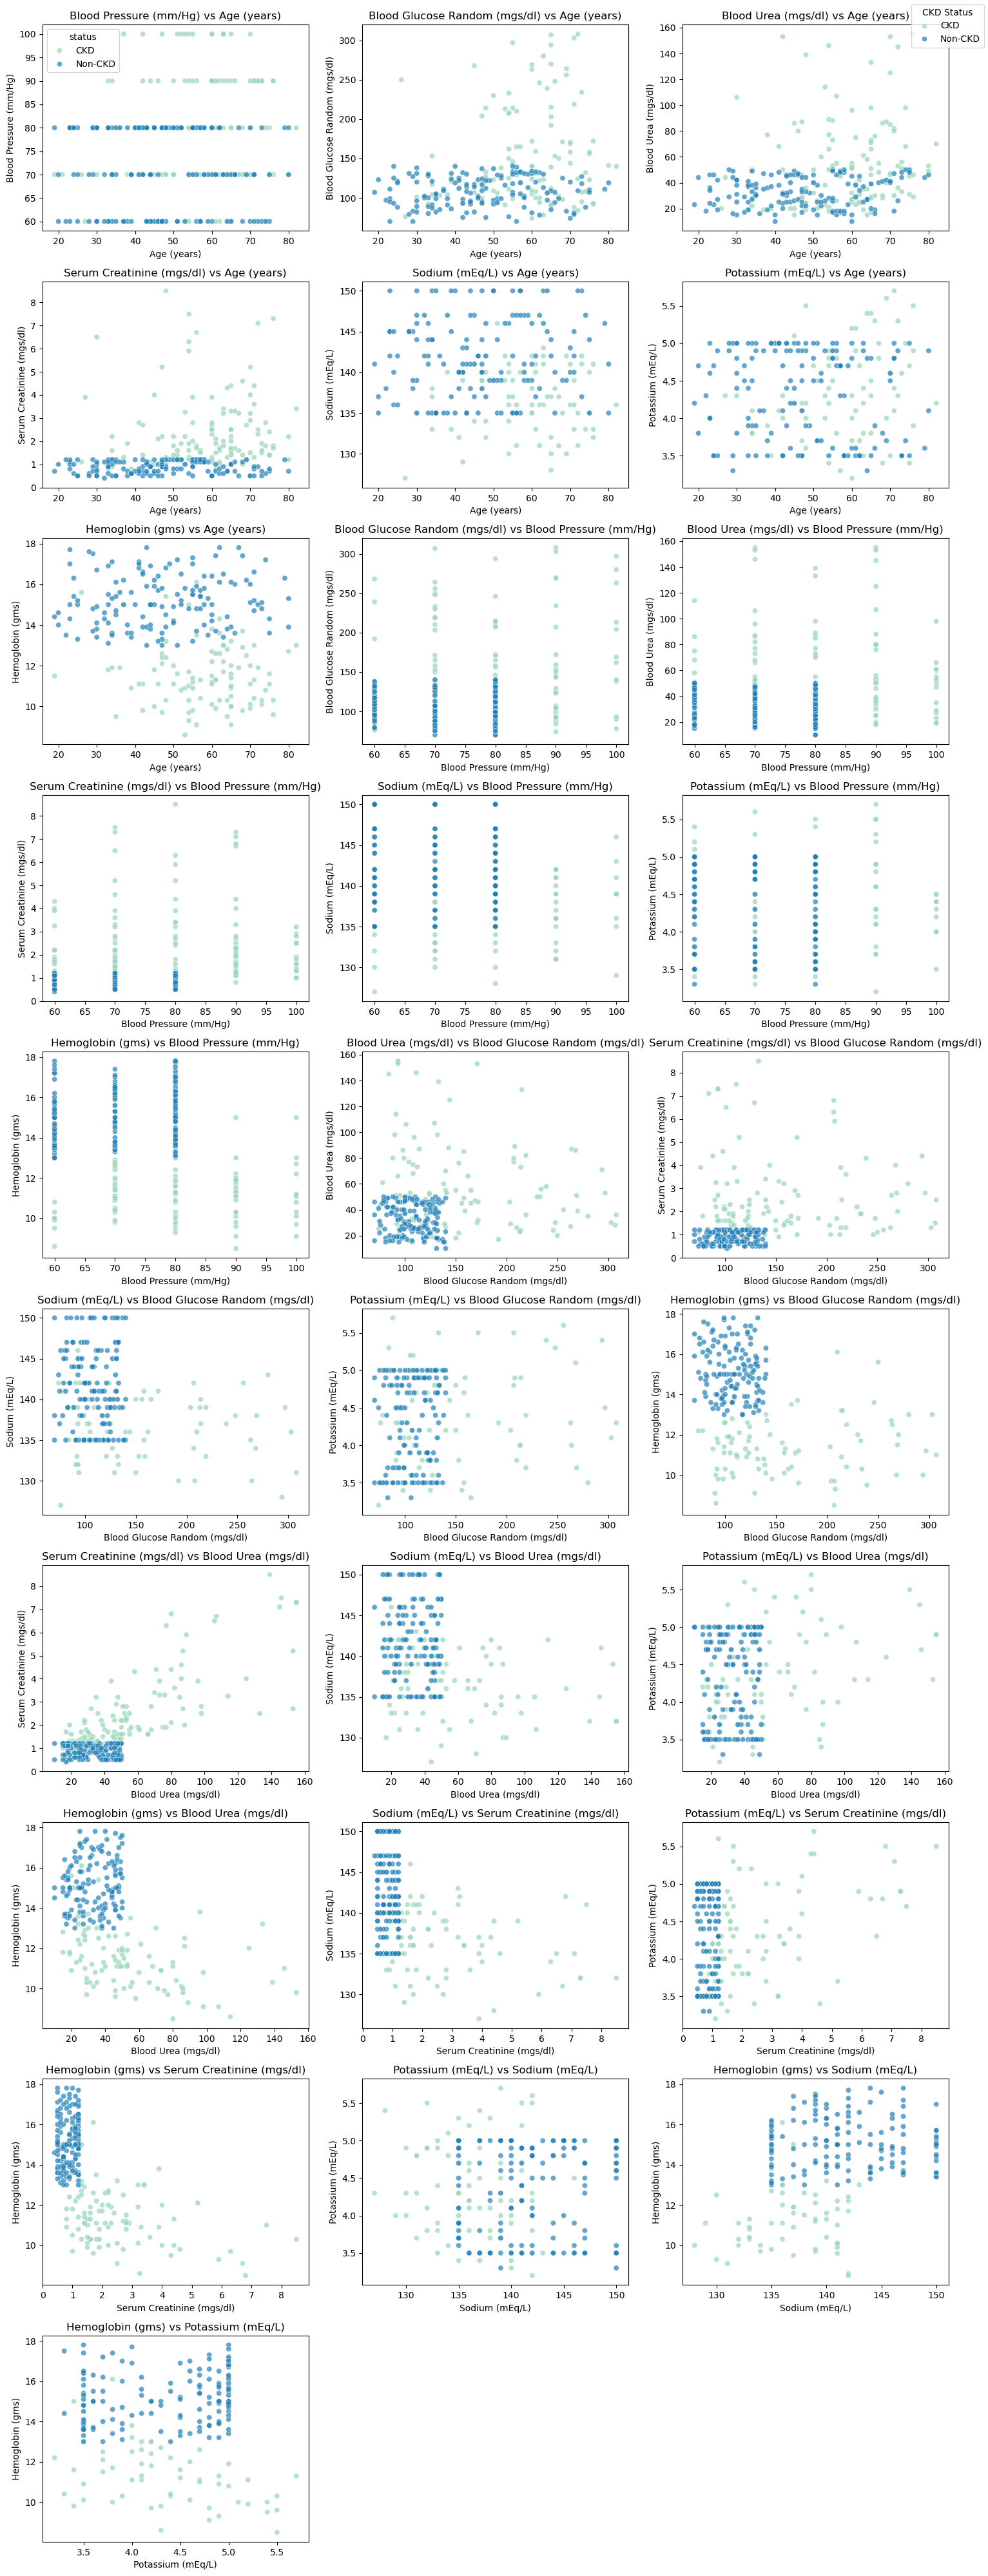

In [28]:
# using only to make the combinations of all numeric variables
from itertools import combinations
import math

pairs = list(combinations(numeric_vars, 2))  # 28 pairs

n_cols = 3
n_rows = math.ceil(len(pairs) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, ((x_var, y_var), ax) in enumerate(zip(pairs, axes)):
    scatterplot_by_group(
        cleaned_dataframe,
        x_var=x_var,
        y_var=y_var,
        group_col='status',
        ax=ax,
        name_map=full_numeric_names,
        show_legend=(idx == 0)  # legenda len v prvom grafe
    )
for ax in axes[len(pairs):]:
    ax.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='CKD Status',
    loc='upper right'
)

plt.tight_layout()
plt.show()


The dataset shows that chronic kidney disease is most strongly associated with direct kidney function markers. Serum creatinine and blood urea have a clear positive correlation, especially in CKD patients. Hemoglobin shows a strong negative relationship with both creatinine and urea, indicating anemia as kidney function worsens. These three variables clearly separate CKD from non-CKD cases. Age and blood pressure show only moderate relationships and act more as risk factors than direct indicators. Blood glucose has an indirect association, suggesting a contributing but not defining role. Sodium and potassium remain relatively stable and show little meaningful correlation. Overall, kidney function and hematological markers explain the dataset far better than electrolytes or demographics.

** (3) Generate subject_id and trial columns from name and remove name**

Adding a subject_id column to uniquely identify each patient in the dataset. This is particularly useful for tracking individual patients across analyses or models. The subject_id is generated by creating a unique integer for each row in the cleaned dataframe starting form 1 to 145, with the letter `S` prefixed to indicate subject ID and it is added as a first column in the dataframe.

In [29]:
cleaned_dataframe = cleaned_dataframe.reset_index(drop=True)

cleaned_dataframe['subject_id'] = (
    'S' + (cleaned_dataframe.index + 1).astype(str).str.zfill(2)
)
cols = ['subject_id'] + [c for c in cleaned_dataframe.columns if c != 'subject_id']
cleaned_dataframe = cleaned_dataframe[cols]
cleaned_dataframe.head(145)

,subject_id,age,bp,rbc,pc,pcc,ba,bgr,bu,sc,...,al_2.0,al_3.0,al_4.0,al_5.0,su_0.0,su_1.0,su_2.0,su_3.0,su_4.0,su_5.0
0,S01,48.0,80.0,NaN,1.0,0.0,0.0,121.0,36.0,1.2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,S02,51.0,80.0,1.0,1.0,0.0,0.0,106.0,26.0,1.4,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,S03,60.0,90.0,NaN,NaN,0.0,0.0,74.0,25.0,1.1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,S04,52.0,100.0,1.0,0.0,1.0,0.0,138.0,60.0,1.9,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,S05,68.0,70.0,NaN,NaN,0.0,0.0,98.0,86.0,4.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,S141,34.0,80.0,1.0,1.0,0.0,0.0,121.0,27.0,1.2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
141,S142,60.0,80.0,1.0,1.0,0.0,0.0,131.0,10.0,0.5,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
142,S143,38.0,60.0,1.0,1.0,0.0,0.0,91.0,36.0,0.7,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
143,S144,42.0,80.0,1.0,1.0,0.0,0.0,98.0,20.0,0.5,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


- Numerical variables were aggregated by CKD status using the group and average function, resulting in the creation of an `aggregated_dataframe` 
- A reusable scatterplot function was implemented to explore relationships between numerical variables, with observations grouped by CKD status. While the function supports optional group-specific trend lines, the primary analysis focused on scatterplots without trend lines to assess overlap, correlation structure, and potential linear separability across multiple variable pairs
- Finally, a unique subject_id was generated to ensure clear identification of individual records. As the dataset does not contain trial-based or repeated-measurement data, the subject_id is included in the `cleaned_dataframe` 